<div style="background-color: #f3e5f5; padding: 25px; border-radius: 15px; border: 2px solid #7b1fa2; box-shadow: 2px 2px 8px rgba(0,0,0,0.1); text-align: center; direction: rtl; font-family: 'Vazir', Tahoma, sans-serif;">
<div style="color: #4a148c; font-size: 2em; font-weight: bold; margin-bottom: 8px;">کتاب درک شهودی یادگیری ماشین</div>
<hr style="border: none; border-top: 2px solid #7b1fa2; width: 50%; margin: 12px auto;">
<h2 style="color: #4a148c; margin: 0; font-size: 1.5em; border-bottom: none;">فصل چهاردهم: ماشین‌های بردار پشتیبان (رگرسیون)</h2>
</div>

<div dir="rtl" align="right">

# مثال عملی رگرسیون با ماشین بردار پشتیبان

در SVR، خروجی عددی است. نخست روی دادهٔ حقوق، ورودی و هدف را استاندارد می‌کنیم؛ سپس برآورد را به مقیاس اصلی حقوق برمی‌گردانیم. مقایسهٔ سه کرنل روی دادهٔ مصنوعی در پایان نوت‌بوک آمده است.

</div>

<div dir="rtl" align="right">

## آماده‌سازی
سلول‌ها را از بالا به پایین اجرا کنید. فایل‌های داده در پوشهٔ `data` قرار دارند. وابستگی‌ها در `requirements.txt` مشخص شده‌اند.

</div>

In [1]:
# آماده‌سازی
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# پوشهٔ داده کنار پوشهٔ نوت‌بوک‌ها قرار دارد.
DATA = Path("../data")
if not DATA.is_dir():
    DATA = Path("data")
if not DATA.is_dir():
    raise FileNotFoundError("Open notebook from the extracted bundle.")
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11})

<div dir="rtl" align="right">

## 1. خواندن دادهٔ حقوق

Level سطح شغلی است، نه تعداد سال‌های سابقه. داده فقط ده ردیف دارد؛ این مثال شکل برازش را نشان می‌دهد و آزمون مستقلی برای تعمیم ندارد.

</div>

In [2]:
# خواندن دادهٔ حقوق
data = pd.read_csv(DATA / "Position_Salaries.csv")
X = data[["Level"]].to_numpy()
y = data["Salary"].to_numpy()
grid = np.arange(float(X.min()), float(X.max()) + 0.01, 0.01).reshape(-1, 1)
display(data)

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


<div dir="rtl" align="right">

## 2. آموزش با تبدیل ورودی و هدف

TransformedTargetRegressor تبدیل هدف و تبدیل معکوسِ پیش‌بینی را انجام می‌دهد. بنابراین محور حقوق در نمودار، واحد اصلی فایل را دارد.

</div>

Estimate at level 6.5: 170370.02040650236


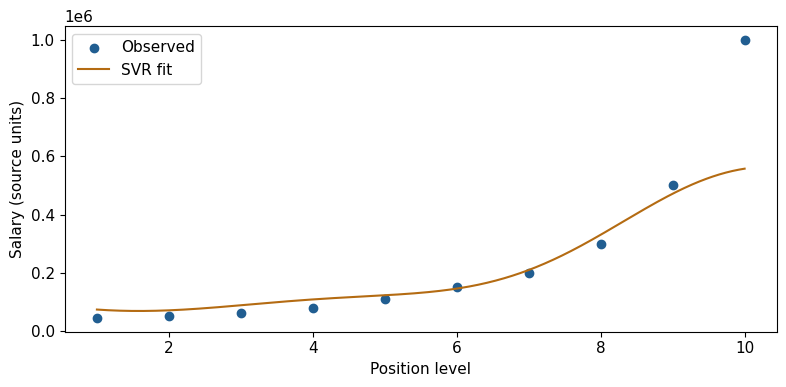

In [3]:
# آموزش با تبدیل ورودی و هدف
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(), SVR(kernel="rbf")),
    transformer=StandardScaler())
model.fit(X, y)
print("Estimate at level 6.5:", model.predict([[6.5]])[0])
plt.scatter(X[:, 0], y, color="#215e91", label="Observed")
plt.plot(grid[:, 0], model.predict(grid), color="#b46b12", label="SVR fit")
plt.xlabel("Position level")
plt.ylabel("Salary (source units)")
plt.legend()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## 3. آزمایش تکمیلی سه کرنل روی دادهٔ مصنوعی

این داده عمداً مصنوعی است. بذر ثابت باعث تکرارپذیری می‌شود. نمودار، برازش روی همان نقاط آموزش را نشان می‌دهد.

</div>

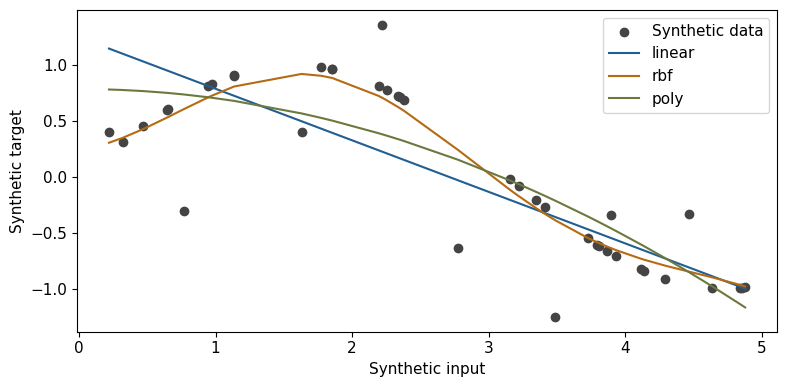

In [4]:
# آزمایش تکمیلی سه کرنل روی دادهٔ مصنوعی
rng = np.random.default_rng(42)
synthetic_X = np.sort(5 * rng.random((40, 1)), axis=0)
synthetic_y = np.sin(synthetic_X).ravel()
synthetic_y[::5] += 3 * (0.5 - rng.random(8))
plt.scatter(synthetic_X[:, 0], synthetic_y, color="#444444", label="Synthetic data")
for kernel, color in [("linear", "#215e91"), ("rbf", "#b46b12"),
                       ("poly", "#6b793e")]:
    svr = SVR(kernel=kernel, C=1e4, gamma=0.1, degree=2)
    svr.fit(synthetic_X, synthetic_y)
    plt.plot(synthetic_X[:, 0], svr.predict(synthetic_X),
             color=color, label=kernel)
plt.xlabel("Synthetic input")
plt.ylabel("Synthetic target")
plt.legend()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## نکتهٔ پایانی
هیچ‌یک از دو نمودار آزمونِ مستقل نیست. هدف، مشاهدهٔ اثر کرنل و مقیاس‌سازی است؛ از آن‌ها برتری قطعی یک مدل نتیجه نمی‌گیریم.

</div>

<div dir="rtl" align="right">

## مأخذ مثال
مراجع فنی: [scikit-learn](https://scikit-learn.org/1.8/user_guide.html)، [pandas](https://pandas.pydata.org/docs/)، [XGBoost](https://xgboost.readthedocs.io/en/stable/python/python_api.html).

</div>